In [4]:
import sys
print(sys.executable)

e:\Langgraph\myenv\Scripts\python.exe


In [2]:
%pip install langgraph

  Using cached langgraph-1.2.6-py3-none-any.whl.metadata (4.9 kB)
  Using cached langchain_core-1.4.8-py3-none-any.whl.metadata (4.7 kB)
  Using cached langgraph_checkpoint-4.1.1-py3-none-any.whl.metadata (5.2 kB)
  Using cached langgraph_prebuilt-1.1.0-py3-none-any.whl.metadata (5.2 kB)
  Using cached langgraph_sdk-0.4.2-py3-none-any.whl.metadata (3.6 kB)
  Using cached xxhash-3.8.0-cp313-cp313-win_amd64.whl.metadata (15 kB)
  Using cached jsonpatch-1.33-py2.py3-none-any.whl.metadata (3.0 kB)
  Using cached langchain_protocol-0.0.18-py3-none-any.whl.metadata (2.4 kB)
  Using cached langsmith-0.9.3-py3-none-any.whl.metadata (21 kB)
  Using cached pyyaml-6.0.3-cp313-cp313-win_amd64.whl.metadata (2.4 kB)
  Using cached tenacity-9.1.4-py3-none-any.whl.metadata (1.2 kB)
  Using cached uuid_utils-0.16.2-cp313-cp313-win_amd64.whl.metadata (6.5 kB)
  Using cached jsonpointer-3.1.1-py3-none-any.whl.metadata (2.4 kB)
  Using cached ormsgpack-1.12.2-cp313-cp313-win_amd64.whl.metadata (3.3 kB)
  

In [5]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [7]:
class bmi_state(TypedDict):
    weight_kg:float
    height_m:float
    bmi:float

In [8]:
def calculate_bmi(state):
    weight=state['weight_kg']
    height=state['height_m']
    bmi=weight/(height**2)
    ans=round(bmi,2)
    state['bmi']=ans
    return state

In [9]:
graph=StateGraph(bmi_state)
graph.add_node("calculate_bmi",calculate_bmi)
graph.add_edge(START,"calculate_bmi")
graph.add_edge("calculate_bmi",END)
workflow=graph.compile()


In [10]:
initial_state={'weight_kg':63,'height_m':1.9}
final_state=workflow.invoke(initial_state)
print(final_state)

{'weight_kg': 63, 'height_m': 1.9, 'bmi': 17.45}


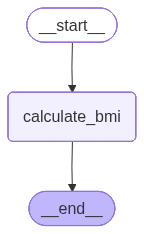

In [10]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())